# 第二組 Project 1：對 PTT 星宇航空相關文章進行情緒分析

- 動機說明
    - 近期星宇動向頻傳，從引發基層熱議的「一個月年終」與 2026 年大規模機隊交付，可見其在資本支出與員工福利間的權衡；而在行銷端，透過邀請蔡依林代言並翻拍經典《布拉格廣場》MV，展現了其插旗歐洲市場的強大品牌野心。然而，面對中東地緣政治引發的燃料供應變數，星宇正逐漸面臨挑戰。

- 困難與解決方法
    - Tarflow 在 PTT 上爬蟲資料有限，因此搭配使用開源[ptt-crawler](https://www.npmjs.com/package/@waynechang65/ptt-crawler)爬蟲，抓取資料。


本分析將藉由彙整 PTT（如 Stock、Aviation 板）之社群輿情，拆解大眾對於星宇「精品行銷」與「經營壓力」的真實看法，評估其在高度不確定的環境下，如何維持品牌溢價並平衡利害關係人期待。

## 大綱
1. 文字雲分析
    - 1.1 資料介紹
    - 1.2 中文斷句、斷詞
    - 1.3 計算去除停用字及更新字典前的詞頻
    - 1.4 移除停用字
    - 1.5 更新斷詞及停用字詞典
    - 1.6 比較清理前後的文字雲
2. 情緒分析(一)
    - 2.1 準備LIWC情緒字典
    - 2.2 情緒字典與斷詞結果進行合併
    - 2.3 正負向情緒詞彙頻率折線圖圖
    - 2.4 正負向情緒詞彙比例折線圖圖
    - 2.5 正負向情緒分數折線圖圖
    - 2.6 文章為單位的情緒分析
    - 2.7 情緒代表字
    - 2.8 文字雲
3. 情緒分析(二)
    - 3.1 安裝CKIP
    - 3.2 CKIP 標註
    - 3.3 探索分析 - NER
    - 3.4 探索分析 - POS
4. 利用SnowNLP進行情緒分析


In [2]:
import pandas as pd
import jieba
import jieba.analyse
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import time
%matplotlib inline


In [3]:
# 設定文字雲中文字體路徑
font_path = "raw_data/SourceHanSansTW-Regular.otf"

# 設定圖的字體大小
plt.rcParams['font.size'] = 14

# 1) 將字體檔案加入到 matplotlib 的字體庫
fm.fontManager.addfont(font_path)

# 2) 建立 FontProperties 物件
fprop = fm.FontProperties(fname=font_path)

# 3) 設定整體的 font.family 為此字體
plt.rcParams['font.family'] = fprop.get_name()


## 1. 文字雲分析

### 1.1 資料介紹
資料來源：
- 使用開源[ptt-crawler](https://www.npmjs.com/package/@waynechang65/ptt-crawler)爬蟲，抓取PTT 文章。
- 版：「Aviation」、「Stock」
- 標題關鍵字：「星宇」
- 時間: 2025-12-01 ~ 2026-03-18

In [4]:
# 讀取星宇航空的 PTT 文章資料
df = pd.read_csv("raw_data/starlux_dataset.csv")
df.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到
3,3,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:54,comment,susan06374,金城武都選長榮 你參考
4,4,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 17:09,comment,MTBF,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到


#### 資料初步清理
- 清除內文為空值的文章

- 透過觀察發現ptt的文章常用兩個換行符號作為句子的結尾，因此將兩個換行取代為句號。

- 清除不重要的字如換行

In [5]:
clear_df = df.copy()

# 將 artDate 轉換為 datetime 格式，並只保留日期部分
clear_df["artDate"] = pd.to_datetime(clear_df["artDate"])
clear_df['artDate'] = clear_df['artDate'].dt.date 

#去除文章內容為空值的筆數
clear_df.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

# 新增 sentence 欄位：先把跳脫字元換回換行，再做清理
clear_df['sentence'] = clear_df['artContent'].str.replace(r'\\n', '\n', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n\n', '。', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n', '', regex=True)


#移除內文中的網址
clear_df['sentence'] = clear_df['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentence
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣。星宇 星加坡 長榮會怎麼選呢?。看票價星宇是便宜蠻多的 不明白怎麼差那麼多...
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的 我最近也有注意到
3,3,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,susan06374,金城武都選長榮 你參考,金城武都選長榮 你參考
4,4,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,MTBF,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到
5,5,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,js52666,做頂的,做頂的
6,6,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,zxcvbnm2010,台灣新加坡航線，不管什麼航空基本票價都是一件行李,台灣新加坡航線，不管什麼航空基本票價都是一件行李
7,7,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,mellopaw,經濟？商務？通常我看到都星宇都貴很多欸 每次都覺得他們真敢,經濟？商務？通常我看到都星宇都貴很多欸 每次都覺得他們真敢
8,8,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,dunkylu,你去全家消費可以累積OPENPOINT嗎,你去全家消費可以累積OPENPOINT嗎
9,9,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,lc85301,來這裡問就是搭最貴的,來這裡問就是搭最貴的


### 1.2 中文斷句、斷詞

#### 斷句
中文主要以標點符號進行斷句，並清除空的字串

In [6]:
clear_df['sentence'] = clear_df['sentence'].str.split("[,，。！!？?]{1,}")

sent_df = clear_df.explode('sentence').reset_index(drop=True)

sent_df.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentence
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇 星加坡 長榮會怎麼選呢
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的 不明白怎麼差那麼多@@
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,但是如果選星宇 累計的里程和星加坡長榮應該是分開的
4,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話
5,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢
6,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,還是都用班機時刻選
7,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問大家會怎麼選
8,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,感謝
9,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的


####  斷詞
斷詞引擎設定：使用 Jieba 當作斷詞系統。
Jieba原先內建為簡體字字典，但我們可以使用繁體字典來做為替換，結果會比較好。   
另外可能還有一些專有名詞是沒有被包含在預設字典當中，我們也可以使用自定義字典的方式加入，或者使用參數的形式帶入。

In [7]:
# 參考網址：https://raw.githubusercontent.com/ldkrsi/jieba-zh_TW/master/jieba/dict.txt
jieba.set_dictionary('dict/dict.txt')

x
***正規表達式 (Regular Expression)*** 是透過簡單的特定字符規則，從文本中找尋符合對應規則的字串，幾乎常見的程式語言，都有支援正規表達式的操作。   

以下提供幾個範例：   

+ ```\d```：匹配任何一個數字字符，等同於 [0-9]

+ ```\w```：匹配任何一個單詞字符，包括字母、數字和下劃線，等同於 [a-zA-Z0-9_]

+ ```\s```：匹配任何一個空白字符，包括空格、換行等

+ ```[ ]```：用於定義一個字符集合，匹配集合中的任何一個字符。 例如: [abc] = 匹配字符 a、b 或 c。

+ ```[^ ]```：用於定義一個否定字符集合，匹配不在集合中的任何一個字符。 例如: [^abc] = 匹配除了 a、b 和 c 以外的任何字符。

+ ```+```：匹配前面提及的元素一次或多次。

更多有關正規表達式的用法可參考python官網的[介紹](https://docs.python.org/zh-tw/3/library/re.html)

In [8]:
#去除句子中除了字母、數字、空白字符以外的符號
sent_df['sentence'] = sent_df['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

sent_df.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentence
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇 星加坡 長榮會怎麼選呢
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的 不明白怎麼差那麼多
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,但是如果選星宇 累計的里程和星加坡長榮應該是分開的
4,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話
5,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢
6,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,還是都用班機時刻選
7,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問大家會怎麼選
8,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,感謝
9,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的


使用jieba進行斷詞

In [9]:
word_df = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 去除空值
word_df = word_df.dropna(subset=['word'])

# word_df = word_df.loc[word_df['word'].str.len() > 1]

word_df.head(10)

Building prefix dict from c:\Users\lcswa\Desktop\SMA_G2_PRJ1\dict\dict.txt ...
Dumping model to file cache C:\Users\lcswa\AppData\Local\Temp\jieba.u44312bdf589509131466a742e78baddd.cache
Loading model cost 0.825 seconds.
Prefix dict has been built successfully.


,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,飛
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,長榮


### 1.3 計算去除停用字及更新字典前的詞頻

In [10]:
freq_df = pd.DataFrame(word_df['word'].value_counts()).sort_values(by = ['count'], ascending = False).reset_index()
freq_df.head(10)

,word,count
0,,4506
1,的,2868
2,是,1413
3,了,1033
4,就,912
5,星宇,792
6,有,774
7,都,748
8,不,696
9,在,620


#### 繪製詞頻為前10高的長條圖

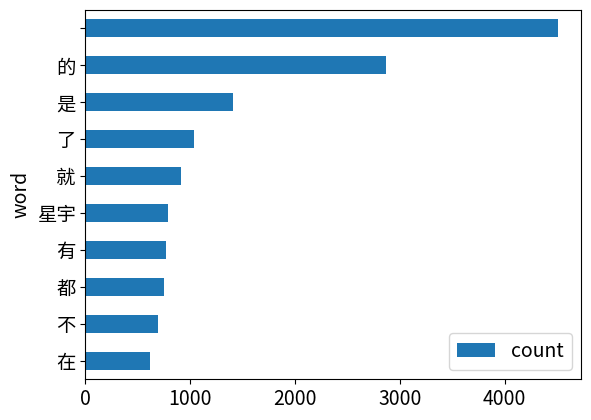

In [11]:
freq_df.head(10).plot.barh(x = 'word', y = 'count').invert_yaxis()
plt.show()

#### 繪製文字雲

In [12]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict = freq_df.set_index('word').to_dict()
freq_dict = freq_dict['count']

print(dict(list(freq_dict.items())[:10]))

{' ': 4506, '的': 2868, '是': 1413, '了': 1033, '就': 912, '星宇': 792, '有': 774, '都': 748, '不': 696, '在': 620}


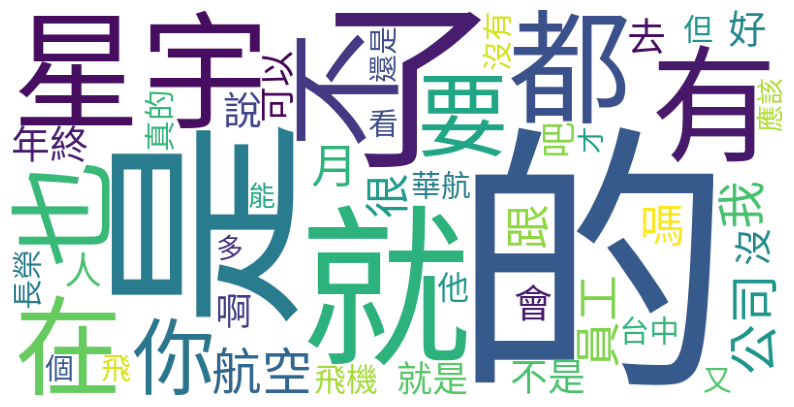

In [13]:
# 繪製文字雲
wordcloud = WordCloud(background_color = 'white', width = 800, height = 400, font_path = font_path, max_words = 50) #max_words: 詞頻前50高
wordcloud.generate_from_frequencies(freq_dict)

plt.figure(figsize = (10,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [14]:
#去除少於兩個字的詞語
word_df = word_df.loc[word_df['word'].str.len() > 1]

計算詞頻並繪製長條圖

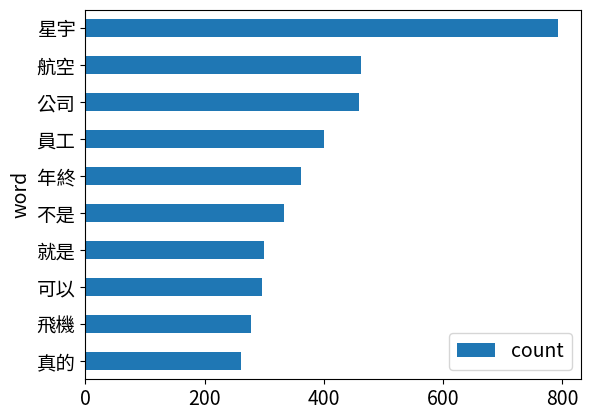

In [15]:
freq_df = pd.DataFrame(word_df['word'].value_counts()).sort_values(by = ['count'], ascending = False).reset_index()

freq_df.head(10).plot.barh(x = 'word', y = 'count').invert_yaxis()

plt.show()

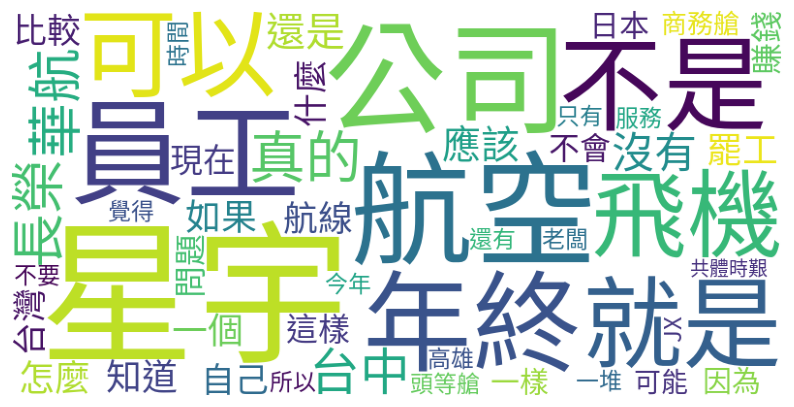

In [16]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict = freq_df.set_index('word').to_dict()
freq_dict = freq_dict['count']

# 繪製文字雲
wordcloud_no1 = WordCloud(background_color = 'white', width = 800, height = 400, font_path = font_path, max_words = 50)
wordcloud_no1.generate_from_frequencies(freq_dict)

plt.figure(figsize = (10,7))
plt.imshow(wordcloud_no1)
plt.axis('off')
plt.show()

### 1.4 移除停用字

In [17]:
# 以檔案形式匯入通用的停用字檔案
# 將stopwords存成list
stopwords = [line.strip() for line in open('dict/stopwords.txt', 'r', encoding='utf-8').readlines()]

移除dataframe中的停用字

In [18]:
noStop_df = word_df[~word_df['word'].isin(stopwords)]

noStop_df.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,長榮
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,票價
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,便宜
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,明白


計算去除停用字後的詞頻

C:\Users\lcswa\AppData\Local\Temp\ipykernel_8020\583685406.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  freq_df_nostop = pd.DataFrame(pd.value_counts(noStop_df['word'])).sort_values(by = ['count'], ascending = False).reset_index()


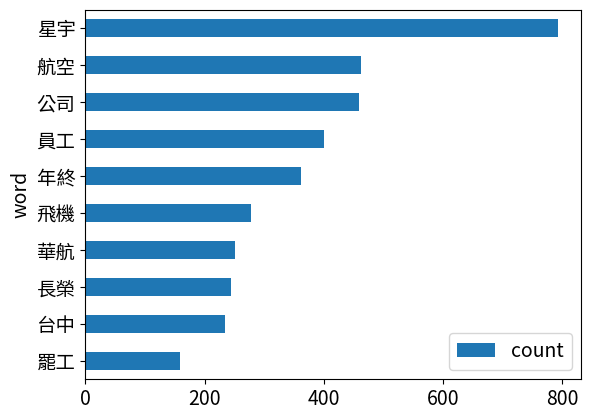

In [19]:
freq_df_nostop = pd.DataFrame(pd.value_counts(noStop_df['word'])).sort_values(by = ['count'], ascending = False).reset_index()

freq_df_nostop.head(10).plot.barh(x = 'word', y = 'count').invert_yaxis()
plt.show()

再次繪製文字雲

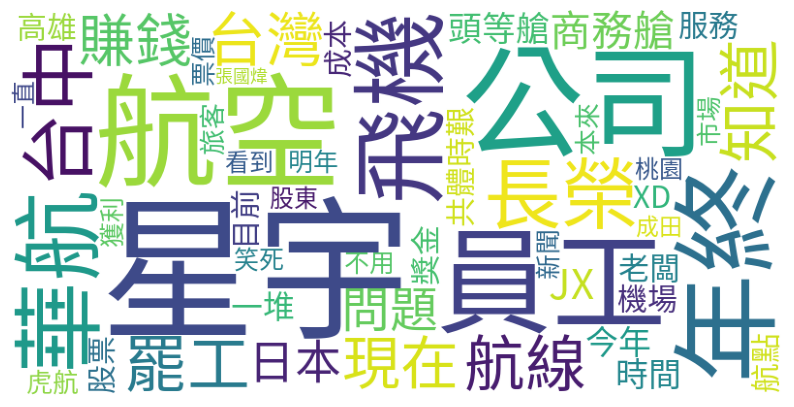

In [20]:
freq_dict_nostop = freq_df_nostop.set_index('word').to_dict()
freq_dict_nostop = freq_dict_nostop['count']

# 繪製文字雲
wordcloud_nostop = WordCloud(background_color = 'white', width = 800, height = 400, font_path = font_path, max_words = 50)
wordcloud_nostop.generate_from_frequencies(freq_dict_nostop)

plt.figure(figsize = (10,7))
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.show()

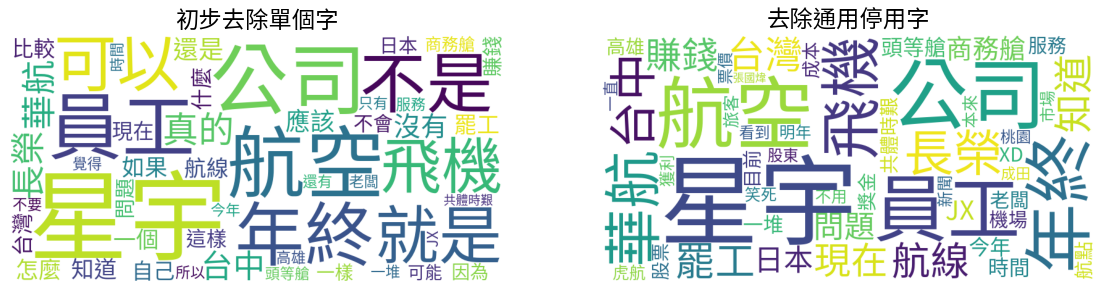

In [21]:
plt.figure(figsize = (14,8))

plt.subplot(1,2,1)
plt.imshow(wordcloud_no1)
plt.axis('off')
plt.title("初步去除單個字")

plt.subplot(1,2,2)
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.title("去除通用停用字")

plt.show()

### 1.5 更新停用字及斷詞字典

#### 更新停用字

In [22]:
# 參數形式手動加入停用字
stopwords_manual = ["知道", "現在", "一堆", "本來", "一直", "看到", "目前", "不用", "直接", "明年", "10", "這種", "一點", "根本", "表示", 
                    "一下", "反正", "繼續", "好像", "好了", "去年", "未來", "需要", "使用", "之後", "太多", "今天", "回來", "機會", "增加", 
                    "樓上", "感覺", "會不會", "101", "工作", "一年", "選擇", "加入", "更多", "考慮", "聽到", "預計", "339", "空間",
                    "出發", "不可能", "今年", "時間", "經營", "需求", "以後", "能力", "當初", "原文", "不發", "幾年", "至少", "過去", "最後", 
                    "有沒有", "還在", "準備", "小時", "以前", "位置", "持續", "提供", "幹嘛", "認為", "標題", "有什麼", "幾個", "看看", "14", 
                    "網路", "討論", "重點", "變成", "系統", "兩家", "裡面", "要不要", "只能", "來源", "這麼多", "尤其", "規模", "事情", "完全", 
                    "原來", "條件", "最近", "指出", "決定", "一次", "地方", "連結", "每週", "代表", "關係", "發現", "造成", "遇到", "日期", "359",
                    "謝謝", "15", "引述", "相關", "內部", "銘言", "XD","笑死","張國煒","開航","廁所","希望","精品","資方","新聞","落地", "客人",
                    "董仔","下去","那麼多","廣體機","美東","XDD","董事長","廣體", "產業","艙等","東南亞","桃機","每周","TPE","餐點","網友","787","理由", 
                    "分享","來回","完成","12","聽說","客運","東西","情況","反串","設計", "羽田","新航線","期間","芬蘭","Lulu","有夠","回程","兩個","每年"]
stopwords.extend(stopwords_manual)

In [23]:
noStop_df_2 = noStop_df[~noStop_df['word'].isin(stopwords)]
noStop_df_2.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,長榮
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,票價
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,便宜
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,明白


C:\Users\lcswa\AppData\Local\Temp\ipykernel_8020\2791560549.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  freq_df_nostop_2 = pd.DataFrame(pd.value_counts(noStop_df_2['word'])).sort_values(by = ['count'], ascending = False).reset_index()


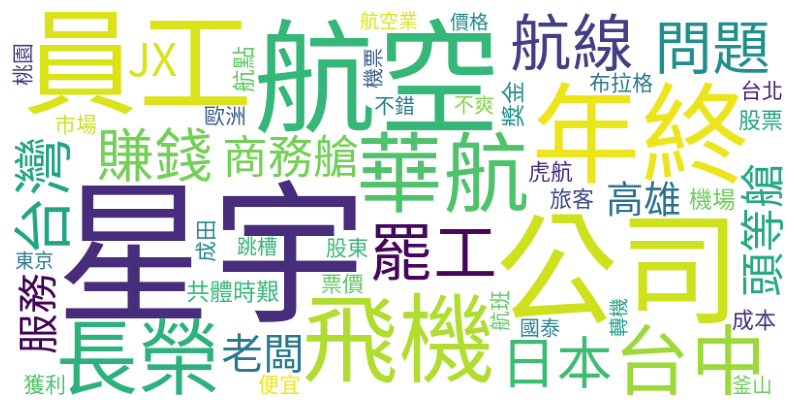

In [24]:
# 計算詞頻
freq_df_nostop_2 = pd.DataFrame(pd.value_counts(noStop_df_2['word'])).sort_values(by = ['count'], ascending = False).reset_index()

# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict_nostop_2 = freq_df_nostop_2.set_index('word').to_dict()
freq_dict_nostop_2 = freq_dict_nostop_2['count']

# 繪製文字雲
wordcloud_nostop_2 = WordCloud(background_color = 'white', width = 800, height = 400, font_path = font_path, max_words = 50)
wordcloud_nostop_2.generate_from_frequencies(freq_dict_nostop_2)

plt.figure(figsize = (10,7))
plt.imshow(wordcloud_nostop_2)
plt.axis('off')
plt.show()


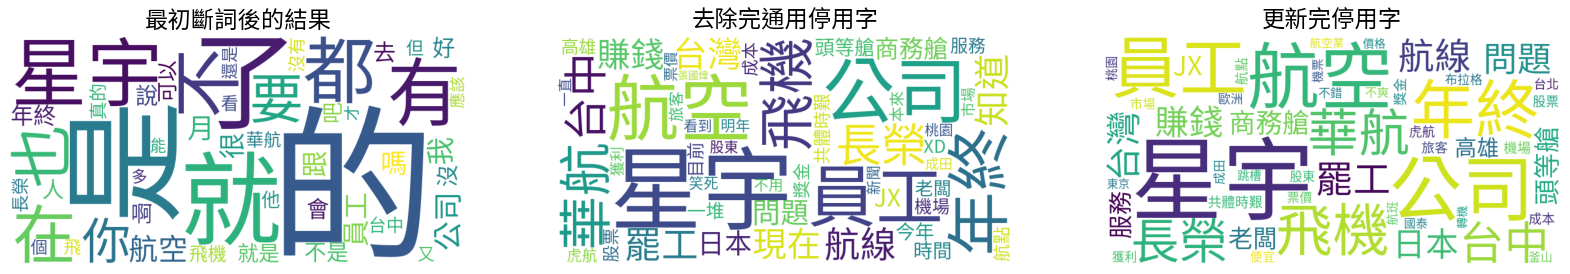

In [25]:
plt.figure(figsize = (20,14))

plt.subplot(1,3,1)
plt.imshow(wordcloud)
plt.axis('off')
plt.title("最初斷詞後的結果")

plt.subplot(1,3,2)
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.title("去除完通用停用字")

plt.subplot(1,3,3)
plt.imshow(wordcloud_nostop_2)
plt.axis('off')
plt.title("更新完停用字")

plt.show()

#### 更新斷詞字典
更新斷詞字典有兩種方法

a. 自行定義的斷詞字典

In [26]:
# 載入自定義辭典：一個詞一行，每行分詞語、詞頻(可省)、詞性(可省)
jieba.load_userdict("./dict/user_dict.txt")

b. 參數形式手動加入字詞

In [27]:
freq_df_nostop_2.head(50)

,word,count
0,星宇,792
1,航空,463
2,公司,459
3,員工,400
4,年終,362
5,飛機,278
6,華航,251
7,長榮,244
8,台中,234
9,罷工,158


In [28]:
tokens = noStop_df_2['word'].tolist()

from collections import Counter

bigrams = Counter(zip(tokens[:-1], tokens[1:]))

bigrams.most_common(20)

[(('星宇', '航空'), 190),
 (('航空', '公司'), 81),
 (('年終', '獎金'), 66),
 (('長榮', '華航'), 37),
 (('華航', '長榮'), 29),
 (('星宇', '員工'), 29),
 (('員工', '年終'), 27),
 (('公司', '賺錢'), 21),
 (('星宇', '飛機'), 18),
 (('新創', '公司'), 18),
 (('台中', '成田'), 17),
 (('on', 'my'), 16),
 (('商務艙', '旅客'), 15),
 (('搭乘', '星宇'), 14),
 (('年終', '公司'), 14),
 (('長榮', '航空'), 12),
 (('員工', '福利'), 12),
 (('傳統', '航空'), 12),
 (('長榮', '星宇'), 12),
 (('from', 'JPTT'), 12)]

In [29]:
jieba.add_word('星宇航空')
jieba.add_word('航空公司')
jieba.add_word('年終獎金')
jieba.add_word('長榮航空')

In [30]:
# 查看目前‘航空公司’出現幾次
noStop_df_2[noStop_df_2['word'] == ('年終獎金')]['word'].count()

0

#### 重新斷詞

In [31]:
# sent_df是還沒斷詞過的df
word_df_updated = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

#把長度小於1的row刪掉
word_df_updated = word_df_updated.loc[word_df_updated['word'].str.len()>1]
word_df_updated

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡
...,...,...,...,...,...,...,...,...,...
10481,4081,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2025-12-31,comment,scotul,財報已經連續幾季走弱，高層卻持續擴張機隊，這種策略本來就會擠壓人事成本,人事
10481,4081,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2025-12-31,comment,scotul,財報已經連續幾季走弱，高層卻持續擴張機隊，這種策略本來就會擠壓人事成本,成本
10482,4082,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2026-01-02,comment,Hifumi1023,公職連調薪都沒有,公職
10482,4082,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2026-01-02,comment,Hifumi1023,公職連調薪都沒有,調薪


#### 重新移除停用字

In [32]:
nostop_df_updated = word_df_updated[~word_df_updated['word'].isin(stopwords)]

nostop_df_updated

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡
...,...,...,...,...,...,...,...,...,...
10481,4081,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2025-12-31,comment,scotul,財報已經連續幾季走弱，高層卻持續擴張機隊，這種策略本來就會擠壓人事成本,擠壓
10481,4081,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2025-12-31,comment,scotul,財報已經連續幾季走弱，高層卻持續擴張機隊，這種策略本來就會擠壓人事成本,人事
10481,4081,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2025-12-31,comment,scotul,財報已經連續幾季走弱，高層卻持續擴張機隊，這種策略本來就會擠壓人事成本,成本
10482,4082,Stock,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...,2026-01-02,comment,Hifumi1023,公職連調薪都沒有,公職


In [33]:
# 查看目前‘航空公司’出現幾次
nostop_df_updated[nostop_df_updated['word'] == ('年終獎金')]['word'].count()

65

In [34]:
jieba.del_word('年終獎金') # 先將‘星宇航空’字詞從斷詞字典中移除
jieba.add_word('年終獎金', freq = 500) # 加上詞頻後重新加入斷詞字典

重新進行斷詞及清除停用字

In [35]:
# sent_df是還沒斷詞過的df
word_df_updated = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

#把長度小於1的row刪掉
word_df_updated = word_df_updated.loc[word_df_updated['word'].str.len()>1]

#去除停用字
nostop_df_updated = word_df_updated[~word_df_updated['word'].isin(stopwords)]

nostop_df_updated.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,長榮
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,票價
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,便宜
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,明白


In [36]:
# 查看調整詞頻之後‘長榮航空’出現幾次
nostop_df_updated[nostop_df_updated['word'] == ('年終獎金')]['word'].count()

65

經過比對可以看到該詞的數量上升，代表該詞更加精準地被拆分了出來。

#### 重新計算詞頻

In [37]:
freq_df_updated = pd.DataFrame(pd.value_counts(nostop_df_updated['word'])).sort_values(by = ['count'], ascending = False).reset_index()

freq_df_updated.head(10)

C:\Users\lcswa\AppData\Local\Temp\ipykernel_8020\1450957720.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  freq_df_updated = pd.DataFrame(pd.value_counts(nostop_df_updated['word'])).sort_values(by = ['count'], ascending = False).reset_index()


,word,count
0,星宇,602
1,員工,400
2,公司,378
3,年終,297
4,飛機,278
5,華航,251
6,台中,234
7,長榮,232
8,星宇航空,204
9,航空,168


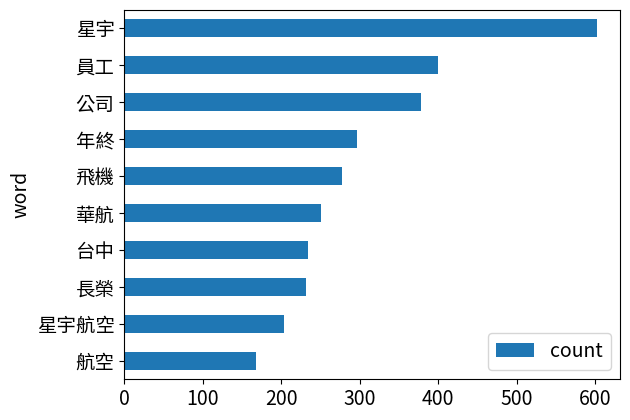

In [38]:
freq_df_updated.head(10).plot.barh(x='word', y='count').invert_yaxis()
plt.show()

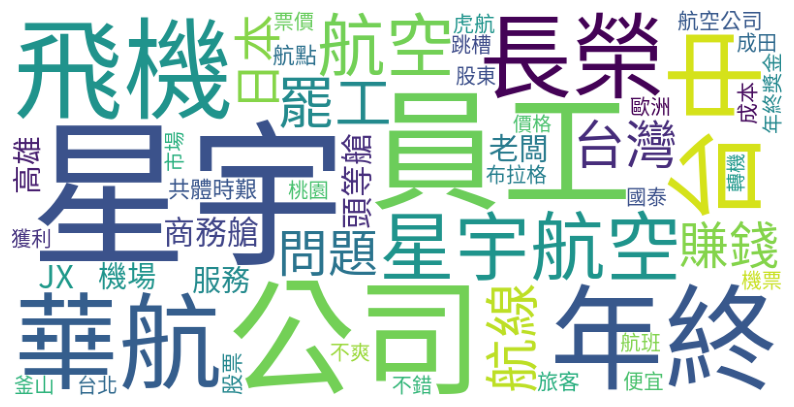

In [39]:
freq_dict_updated = freq_df_updated.set_index('word').to_dict()
freq_dict_updated = freq_dict_updated['count']

# 繪製文字雲
wordcloud_after = WordCloud(background_color='white', width=800, height = 400, font_path = font_path, max_words = 50)
wordcloud_after.generate_from_frequencies(freq_dict_updated)

plt.figure(figsize = (10,7))
plt.imshow(wordcloud_after)
plt.axis('off')
plt.show()

### 1.6 比較清理前後的文字雲

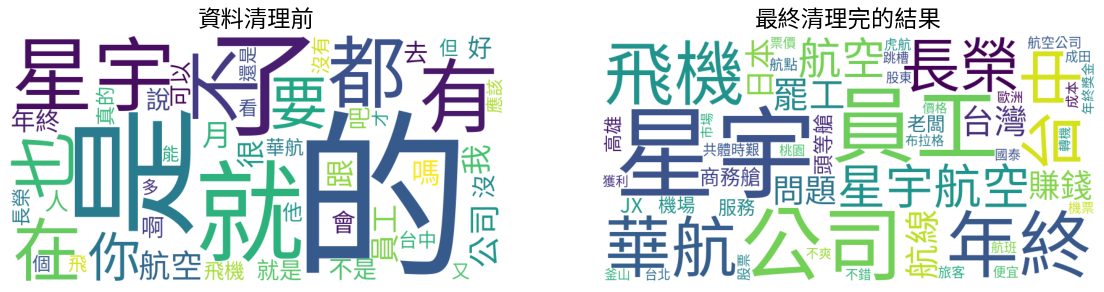

In [40]:
plt.figure(figsize = (14,8))

plt.subplot(1,2,1)
plt.imshow(wordcloud)
plt.axis('off')
plt.title("資料清理前")

plt.subplot(1,2,2)
plt.imshow(wordcloud_after)
plt.axis('off')
plt.title("最終清理完的結果")

plt.show()

儲存clean data，以便後續其他使用

In [41]:
nostop_df_updated.to_csv("raw_data/clean_starlux.csv", encoding = 'utf-8',index = False)

## 2. 情緒分析 (一)
進行基於情緒字典的情緒分析，首先需要準備情緒字典後再將字典與斷詞後的文章進行合併

### 2.1 準備LIWC情緒字典

In [42]:
# 讀取情緒字典
liwc_dict = pd.read_csv("./dict/liwc/LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head()

,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


### 2.2 情緒字典與斷詞結果進行合併
將情緒字典與斷詞結果進行合併。

In [43]:
#共同head: word，去根據情緒字典內容與word和sentiments做對接
ptt_liwc_df = pd.merge(nostop_df_updated[["artUrl", "artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
ptt_liwc_df.head()

,artUrl,artDate,artTitle,artContent,word,sentiments
0,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問,NaN
1,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡,NaN
2,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣,NaN
3,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇,NaN
4,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡,NaN


### 2.3 正負向情緒詞彙頻率折線圖圖
分別畫出文集中，正向（positive）與負向（negative）情緒的折線圖

In [44]:
sentiment_count = pd.DataFrame(
    ptt_liwc_df.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative")
sentiment_count = sentiment_count.loc[mask]

sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])
#sentiment_count.head(10)

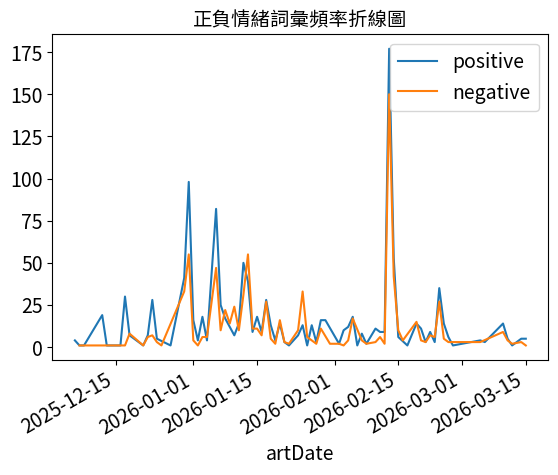

In [45]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

ax.plot(pos["artDate"], pos["size"], color=colors[0], label="positive")
ax.plot(neg["artDate"], neg["size"], color=colors[1], label="negative")

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

```資訊發掘```
- 從趨勢線可以觀察到，在 2025 年 12 月時整體討論量相對平穩，但在進入 2026 年 1 月至 2 月 期間，情緒詞彙的出現頻率產生了巨量的增長。這個時間點恰逢農曆春節旅遊旺季，以及星宇航空發布重大行銷消息（如歐洲新航線佈局、年終獎金開獎等），帶動了社群上的討論。
- 正向和負向詞彙的走勢高度相關。這代表著一個重要現象：當星宇航空的討論度變高時，無論是稱讚（正向）還是抱怨/質疑（負向）的詞彙都會同時增加，高關注度帶動總體討論聲量。
- 儘管在年初的聲量高峰期，負向詞彙也大量湧現，但仔細觀察可以發現，正向的藍線在大多數時間點都穩定的在負向的橘線之上。此意味著即使在輿論討論最激烈、資訊最龐雜的時期，大眾對星宇航空的正面評價與期待，依然壓過了負面批評。

```Moving average```
- rolling average（滾動平均）是一種將時間序列數據平滑化的技術，有助於去除數據中的噪聲，使趨勢更加明顯，同時仍然保留一定的時間特徵。
- 在情緒分析中，特別是當你有一系列時間序列的情緒數據時，使用滾動平均有助於平滑數據，使情緒趨勢更加清晰。
    1. **去除瞬間噪聲**： 情緒數據可能受到瞬間事件或噪聲的影響，例如突發的大量評論或新聞。滾動平均有助於平滑這些突變，使你更容易觀察到整體趨勢。
    2. **強調長期趨勢**： 滾動平均有助於強調長期情緒趨勢，而不受短期波動的干擾。這對於觀察情緒的漸變和長期變化非常有用。


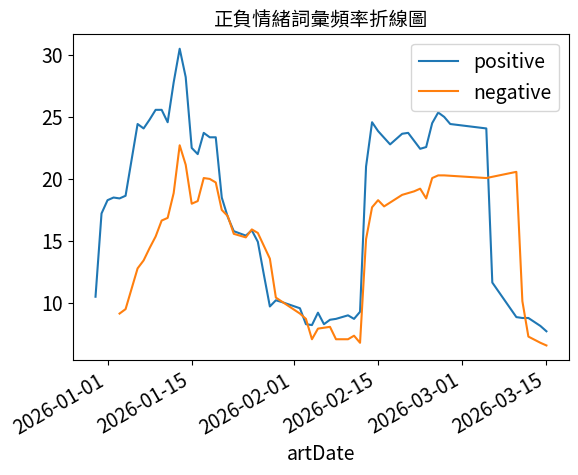

In [46]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0], label="positive")
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1], label="negative")

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

```資訊發掘```
- 經過 SMA 處理後，原本的尖峰被收斂成一個清晰的波段。我們可以觀察到，星宇航空在這段期間的討論熱潮，是從 2026 年 1 月開始穩定爬升，形成一個持續性的高峰，這證實了年初的行銷活動與春節話題，帶來了長達數週的聲量，而非僅是一兩天的短暫熱度。

```詞頻缺點```

如果某一天有什麼事件發生而導致正負向詞頻數隨之飆高，在趨勢圖看來可能會認為該區間的正負向情緒較為顯著，但也有可能是因為總體情緒詞彙本來就比較多而導致的。

以比例的方式來看，我們可以觀察到某個情緒詞在總體情緒詞彙中所佔的比例，就算某一天文章數相較多，也不會影響到比例的呈現。

### 2.4 正負向情緒詞彙比例折線圖圖

In [47]:
sentiment_count = sentiment_count.assign(
    ratio=sentiment_count.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_count.head(10)

,artDate,sentiments,size,ratio
1,2025-12-06,positive,4,1.000000
3,2025-12-07,negative,1,0.500000
4,2025-12-07,positive,1,0.500000
6,2025-12-08,positive,1,1.000000
8,2025-12-12,negative,1,0.050000
9,2025-12-12,positive,19,0.950000
12,2025-12-13,positive,1,1.000000
14,2025-12-16,positive,1,1.000000
16,2025-12-17,negative,1,0.032258
17,2025-12-17,positive,30,0.967742


In [48]:
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

Text(0.5, 1.0, '正負情緒比例折線圖')

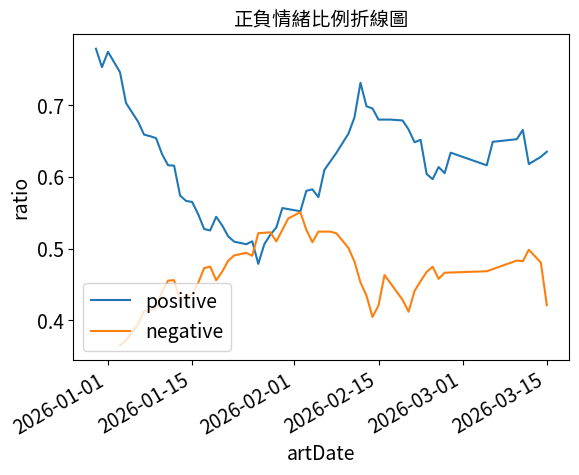

In [49]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(pos["artDate"], pos["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("正負情緒比例折線圖", fontproperties=fprop)

### 2.5 正負向情緒分數折線圖

In [50]:
#用pivot把df的sentiments拆成col
ptt_sentiment_value = (
    sentiment_count.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value.head()

,artDate,negative,positive
0,2025-12-06,0.0,4.0
1,2025-12-07,1.0,1.0
2,2025-12-08,0.0,1.0
3,2025-12-12,1.0,19.0
4,2025-12-13,0.0,1.0


In [51]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value["sentiment_value"] = (
    ptt_sentiment_value["positive"]
    - ptt_sentiment_value["negative"]
)
ptt_sentiment_value.head()

,artDate,negative,positive,sentiment_value
0,2025-12-06,0.0,4.0,4.0
1,2025-12-07,1.0,1.0,0.0
2,2025-12-08,0.0,1.0,1.0
3,2025-12-12,1.0,19.0,18.0
4,2025-12-13,0.0,1.0,1.0


Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

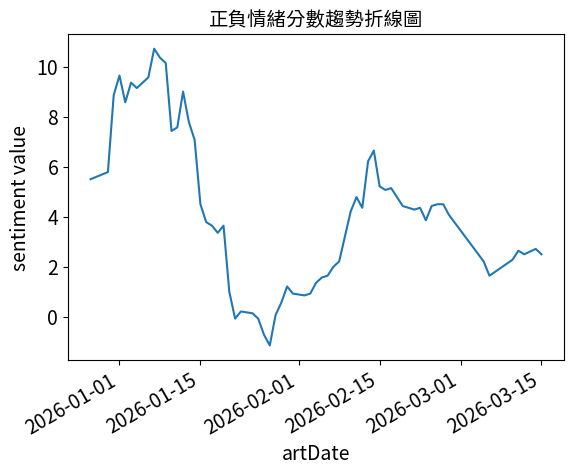

In [52]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(ptt_sentiment_value["artDate"], ptt_sentiment_value["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖", fontproperties=fprop)

### 2.6 文章為單位的情緒分析

In [53]:
sentiment_count_by_article = pd.DataFrame(
    ptt_liwc_df.groupby(["artUrl", "sentiments"]).size()
).reset_index()
sentiment_count_by_article = sentiment_count_by_article.rename(columns={0: "size"})
sentiment_count_by_article.head(10)

,artUrl,sentiments,size
0,https://www.ptt.cc/bbs/Aviation/M.1765003595.A...,affect,7
1,https://www.ptt.cc/bbs/Aviation/M.1765003595.A...,negative,1
2,https://www.ptt.cc/bbs/Aviation/M.1765003595.A...,positive,6
3,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,affect,23
4,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,negative,1
5,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,positive,21
6,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,sad,1
7,https://www.ptt.cc/bbs/Aviation/M.1765968783.A...,affect,39
8,https://www.ptt.cc/bbs/Aviation/M.1765968783.A...,anger,2
9,https://www.ptt.cc/bbs/Aviation/M.1765968783.A...,anx,1


In [54]:
#用pivot把df的sentiments拆成col
ptt_sentiment_value_by_article = (
    sentiment_count_by_article.pivot_table(
        index="artUrl", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value_by_article.head()

,artUrl,affect,anger,anx,negative,positive,sad
0,https://www.ptt.cc/bbs/Aviation/M.1765003595.A...,7.0,0.0,0.0,1.0,6.0,0.0
1,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,23.0,0.0,0.0,1.0,21.0,1.0
2,https://www.ptt.cc/bbs/Aviation/M.1765968783.A...,39.0,2.0,1.0,9.0,30.0,2.0
3,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...,11.0,0.0,1.0,1.0,8.0,0.0
4,https://www.ptt.cc/bbs/Aviation/M.1766398238.A...,48.0,2.0,4.0,14.0,32.0,2.0


In [55]:
# sentiment 計算方式: positive - negative
#下面就單純正面-負面，沒算其他情緒
ptt_sentiment_value_by_article["sentiment_value"] = (
    ptt_sentiment_value_by_article["positive"]
    - ptt_sentiment_value_by_article["negative"]
)
ptt_sentiment_value_by_article.head()

,artUrl,affect,anger,anx,negative,positive,sad,sentiment_value
0,https://www.ptt.cc/bbs/Aviation/M.1765003595.A...,7.0,0.0,0.0,1.0,6.0,0.0,5.0
1,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,23.0,0.0,0.0,1.0,21.0,1.0,20.0
2,https://www.ptt.cc/bbs/Aviation/M.1765968783.A...,39.0,2.0,1.0,9.0,30.0,2.0,21.0
3,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...,11.0,0.0,1.0,1.0,8.0,0.0,7.0
4,https://www.ptt.cc/bbs/Aviation/M.1766398238.A...,48.0,2.0,4.0,14.0,32.0,2.0,18.0


In [56]:
#根據分數+上class欄位
ptt_sentiment_value_by_article['sentiment_class'] = ptt_sentiment_value_by_article['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )
ptt_sentiment_value_by_article.head(10)

,artUrl,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,https://www.ptt.cc/bbs/Aviation/M.1765003595.A...,7.0,0.0,0.0,1.0,6.0,0.0,5.0,正向
1,https://www.ptt.cc/bbs/Aviation/M.1765548760.A...,23.0,0.0,0.0,1.0,21.0,1.0,20.0,正向
2,https://www.ptt.cc/bbs/Aviation/M.1765968783.A...,39.0,2.0,1.0,9.0,30.0,2.0,21.0,正向
3,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...,11.0,0.0,1.0,1.0,8.0,0.0,7.0,正向
4,https://www.ptt.cc/bbs/Aviation/M.1766398238.A...,48.0,2.0,4.0,14.0,32.0,2.0,18.0,正向
5,https://www.ptt.cc/bbs/Aviation/M.1766480053.A...,14.0,0.0,0.0,4.0,9.0,0.0,5.0,正向
6,https://www.ptt.cc/bbs/Aviation/M.1766839858.A...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
7,https://www.ptt.cc/bbs/Aviation/M.1767031107.A...,4.0,0.0,0.0,1.0,2.0,0.0,1.0,正向
8,https://www.ptt.cc/bbs/Aviation/M.1767034491.A...,29.0,0.0,5.0,10.0,18.0,1.0,8.0,正向
9,https://www.ptt.cc/bbs/Aviation/M.1767066330.A...,66.0,9.0,4.0,31.0,32.0,8.0,1.0,正向


In [57]:
clear_df_sentiment = pd.merge(df, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
clear_df_sentiment["artDate"] = pd.to_datetime(clear_df_sentiment["artDate"])
clear_df_sentiment['artDate'] = clear_df_sentiment['artDate'].dt.date

clear_df_sentiment.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentiment_class
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,正向
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,正向
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到,正向
3,3,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,susan06374,金城武都選長榮 你參考,正向
4,4,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,MTBF,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到,正向


In [58]:
sentiment_art_count = pd.DataFrame(
    clear_df_sentiment.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_art_count = sentiment_art_count.rename(columns={0: "size"})
sentiment_art_count = sentiment_art_count.sort_values(["artDate"])
sentiment_art_count

,artDate,sentiment_class,size
0,2025-12-06,正向,10
1,2025-12-07,正向,8
2,2025-12-08,正向,6
3,2025-12-09,正向,2
4,2025-12-12,正向,1
...,...,...,...
128,2026-03-13,負向,1
129,2026-03-14,正向,44
130,2026-03-15,正向,19
131,2026-03-16,正向,5


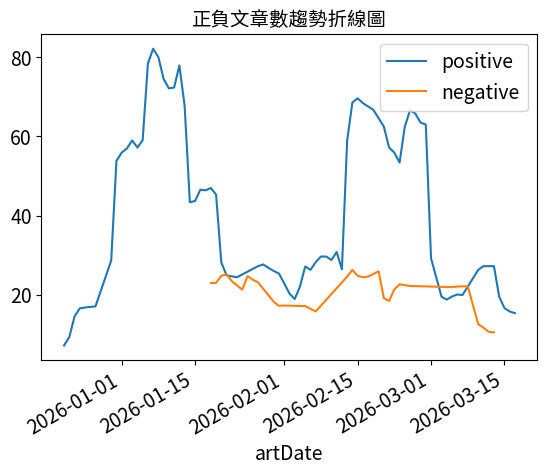

In [59]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_art_count[sentiment_art_count["sentiment_class"] == "正向"]
neg = sentiment_art_count[sentiment_art_count["sentiment_class"] == "負向"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1])
# ax.plot(pos["artDate"], pos['size'], color=colors[0])
# ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負文章數趨勢折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

### 2.7 情緒代表字

In [60]:
word_count = ptt_liwc_df.groupby(["word", "sentiments"]).size().reset_index()
word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_count.head(10)

,word,sentiments,size
216,問題,affect,126
217,問題,negative,126
31,不錯,affect,62
32,不錯,positive,62
19,不爽,negative,56
18,不爽,anger,56
17,不爽,affect,56
299,安全,affect,40
300,安全,positive,40
884,虧損,sad,36


In [61]:
word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_pos.head(15)

,word,sentiments,size
32,不錯,positive,62
300,安全,positive,40
956,重要,positive,36
221,喜歡,positive,32
532,支持,positive,31
779,福利,positive,27
201,合理,positive,26
577,有錢,positive,24
839,肯定,positive,23
712,獎金,positive,22


In [62]:
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]
word_of_neg.head(15)

,word,sentiments,size
217,問題,negative,126
19,不爽,negative,56
883,虧損,negative,36
490,抱怨,negative,25
191,可憐,negative,21
26,不足,negative,16
1005,風險,negative,15
982,隨便,negative,15
243,壓力,negative,14
186,可悲,negative,11


C:\Users\lcswa\AppData\Local\Temp\ipykernel_8020\741308677.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
C:\Users\lcswa\AppData\Local\Temp\ipykernel_8020\741308677.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"], fontproperties=fprop)


Text(0.5, 1.0, '負向情緒總數')

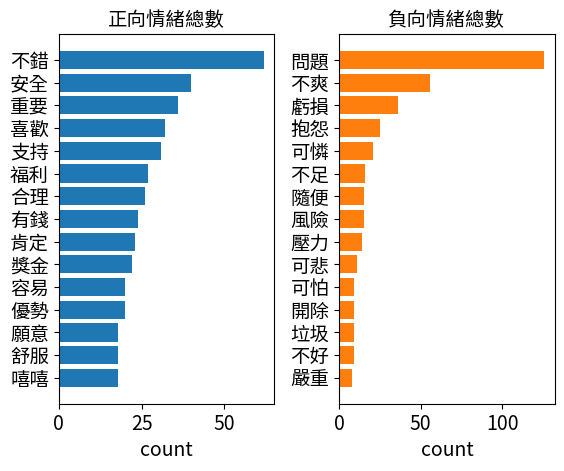

In [63]:
pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)
fig.subplots_adjust(wspace=0.3)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
ax[0].set_title("正向情緒總數", fontproperties=fprop)

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"], fontproperties=fprop)
ax[1].set_title("負向情緒總數", fontproperties=fprop)

In [64]:
filtered_df = sent_df[sent_df['sentence'].str.contains('拒絕', na=False)] #這裡可以依照自己對上面那些詞有興趣自己改
filtered_df.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentence
1271,487,Aviation,[新聞] 星宇通報飛澳門落地資訊 航機未發現異常,https://www.ptt.cc/bbs/Aviation/M.1771430915.A...,2026-02-20,comment,williechen,同樣的訓練同樣的技術同樣的操作同樣的乘客體感 在73 7或舊的321飛機會被判定正常 空巴的...,同樣的訓練同樣的技術同樣的操作同樣的乘客體感 在73 7或舊的321飛機會被判定正常 空巴的...
1317,498,Aviation,[分享] 星宇 JX863 仙台台北 A330neo 商務,https://www.ptt.cc/bbs/Aviation/M.1770888299.A...,2026-02-12,article,s1494041,圖文閱讀版\nhttps://shinnydaily.com/2026/02/12/jx86...,即使重開也不能用有點傻眼 雖然說座艙長有表示可以換位子但只有走道位 想了一下還是拒絕了
1583,620,Aviation,Re: [情報] 星宇航空 8/1 開航布拉格,https://www.ptt.cc/bbs/Aviation/M.1770439842.A...,2026-02-08,comment,nyrnu,星宇過度壓箱在東南亞轉機客經台灣至北美往來需求.川普政策大幅改變需求.連台籍B簽被拒比例大幅...,星宇過度壓箱在東南亞轉機客經台灣至北美往來需求川普政策大幅改變需求連台籍B簽被拒比例大幅升高...
2550,1039,Aviation,[新聞] 他怒「星宇商務艙悶熱」拒再搭 內行說,https://www.ptt.cc/bbs/Aviation/M.1769223085.A...,2026-01-24,article,KW96,他怒「星宇商務艙悶熱」拒再搭 內行說原因：空服員無能為力\n\n2026-01-21 聯合新...,更揚言拒絕再搭星宇


In [65]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

同樣的訓練同樣的技術同樣的操作同樣的乘客體感 在73 7或舊的321飛機會被判定正常 空巴的新系統公式則會被判重落地航空公司可以拒絕升級 但星宇這種全機隊新的就沒得選只能搭載新的系統
即使重開也不能用有點傻眼 雖然說座艙長有表示可以換位子但只有走道位 想了一下還是拒絕了
星宇過度壓箱在東南亞轉機客經台灣至北美往來需求川普政策大幅改變需求連台籍B簽被拒比例大幅升高泰國被列75國暫停核發移民簽證菲越泰等國B簽本來就高拒絕率
更揚言拒絕再搭星宇


#### 重新計算情緒

去除停用詞

In [66]:
# 設定要移除的字詞列表
words_to_remove = ['瘋狂','嚴格','違規','討厭','誤解','壓力','擔心','健康']

# 使用 ~ 運算子和 isin() 方法過濾掉包含在 words_to_remove 列表中的行
liwc_dict_revise = liwc_dict[~liwc_dict['word'].isin(words_to_remove)]
# 使用更新後的情緒字典 merge
ptt_liwc_df_revise = pd.merge(nostop_df_updated[["artUrl", "artDate", "artTitle", "artContent","word"]], liwc_dict_revise, how="left")
#ptt_liwc_df_revise.head()

Text(0.5, 1.0, '負向情緒總數')

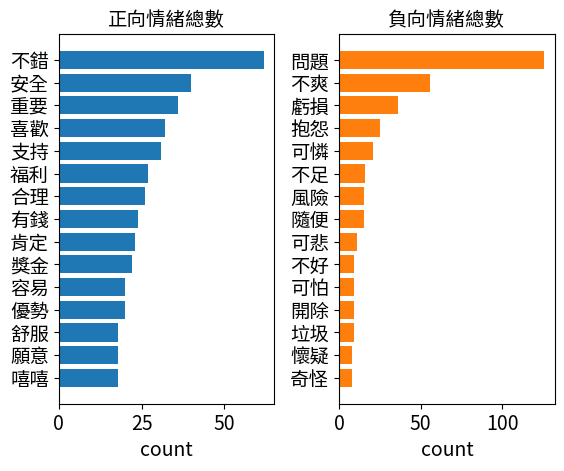

In [67]:
word_count = ptt_liwc_df_revise.groupby(["word", "sentiments"]).size().reset_index()

word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]

pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)
fig.subplots_adjust(wspace=0.3)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticks(range(len(pos["word"])))
ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
ax[0].set_title("正向情緒總數", fontproperties=fprop)

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticks(range(len(neg["word"])))
ax[1].set_yticklabels(neg["word"], fontproperties=fprop)
ax[1].set_title("負向情緒總數", fontproperties=fprop)

重新繪製情緒分數趨勢圖

Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

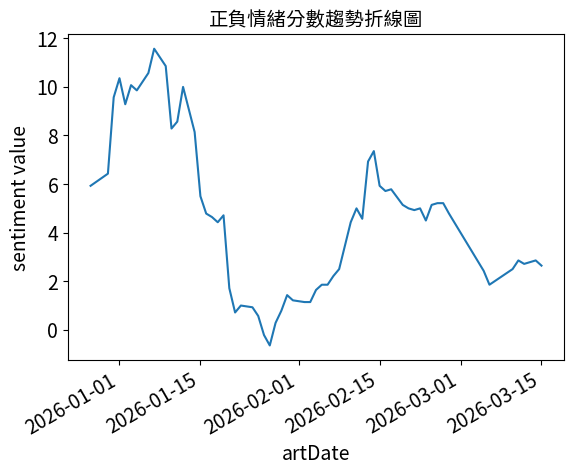

In [68]:
sentiment_count_revise = pd.DataFrame(
    ptt_liwc_df_revise.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count_revise['sentiments'] == "positive") | (sentiment_count_revise['sentiments'] == "negative")
sentiment_count_revise = sentiment_count_revise.loc[mask]

sentiment_count_revise = sentiment_count_revise.rename(columns={0: "size"})
sentiment_count_revise = sentiment_count_revise.sort_values(["artDate"])

ptt_sentiment_value_revise = (
    sentiment_count_revise.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# sentiment 計算方式: positive - negative
ptt_sentiment_value_revise["sentiment_value"] = (
    ptt_sentiment_value_revise["positive"]
    - ptt_sentiment_value_revise["negative"]
)

# 繪製情緒分數趨勢圖
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(ptt_sentiment_value_revise["artDate"], ptt_sentiment_value_revise["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖", fontproperties=fprop)

### 2.8 文字雲

#### 2025-12-01 ~ 2026-03-18 文字雲
將前面計算出的文章情緒類別合併，以利我們過濾出負面文章資料

In [69]:
ptt_liwc_df_revise = pd.merge(ptt_liwc_df_revise, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
ptt_liwc_df_revise.head()

,artUrl,artDate,artTitle,artContent,word,sentiments,sentiment_class
0,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問,NaN,正向
1,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,新加坡,NaN,正向
2,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,台灣,NaN,正向
3,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇,NaN,正向
4,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,加坡,NaN,正向


In [70]:
#sent_df是只有斷句沒斷詞
sent_df = pd.merge(sent_df, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
sent_df.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentence,sentiment_class
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣,正向
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇 星加坡 長榮會怎麼選呢,正向
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的 不明白怎麼差那麼多,正向
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,但是如果選星宇 累計的里程和星加坡長榮應該是分開的,正向
4,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話,正向


In [71]:
date = "2025-12-01"
end_date = "2026-03-18"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "負向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask]
#ptt_df_wc.head(10)

In [72]:
date = "2025-12-01"
end_date = "2026-03-18"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "負向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["artDate", "word"]]


word_count_count = pd.DataFrame(
    ptt_df_wc.groupby(["word"]).size()
).reset_index().rename(columns={0: "size"})

word_count_count = word_count_count.sort_values(by='size', ascending=False)
word_count_count.head(10)

,word,size
1975,星宇,159
1109,問題,134
3564,頭等艙,88
2910,虧損,75
1104,商務艙,67
3595,飛機,62
2876,華航,59
1515,年終,58
804,公司,57
2756,罷工,52


(-0.5, 1599.5, 799.5, -0.5)

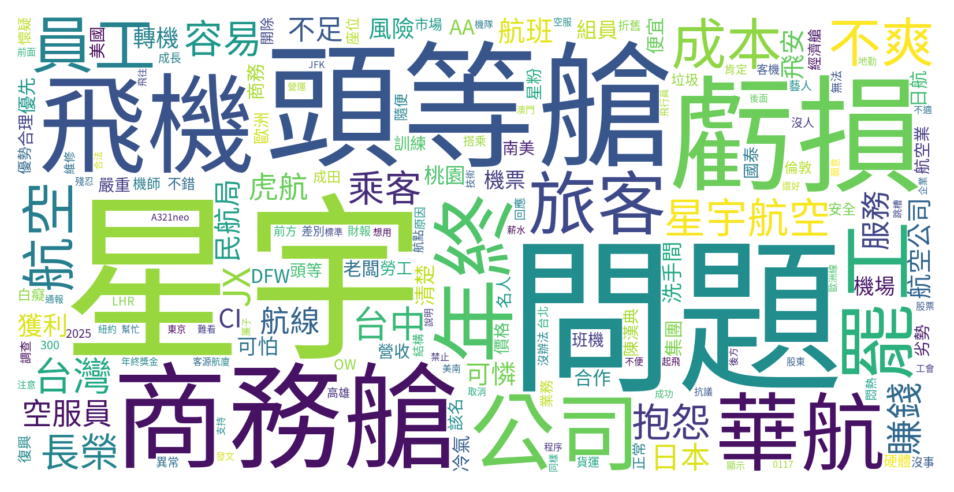

In [73]:
# wordcloud 的 input 是 dictionary
font_path = "raw_data/SourceHanSansTW-Regular.otf"  # 中文字型路徑
wc_dict = dict(zip(word_count_count['word'], word_count_count['size']))
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path)
cloud.generate_from_frequencies(wc_dict)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
# plt.show()

```資訊發掘```
- 除星宇詞外，圖中明顯的字「年終、罷工、虧損、獎金」顯示了年初聲量狂飆的主軸，大眾的討論焦點並非一般客訴，而是高度集中在公司虧損與員工年終/潛在罷工的激烈勞資爭議上。
- 圖中不僅出現巨大的「華航」，還伴隨著「長榮」、「虎航」等競品名稱。這顯示星宇在這段期間的聲量並非孤立存在，網友熱衷將各家航空的勞資議題（如年終、罷工風險）與福利進行共同比較。

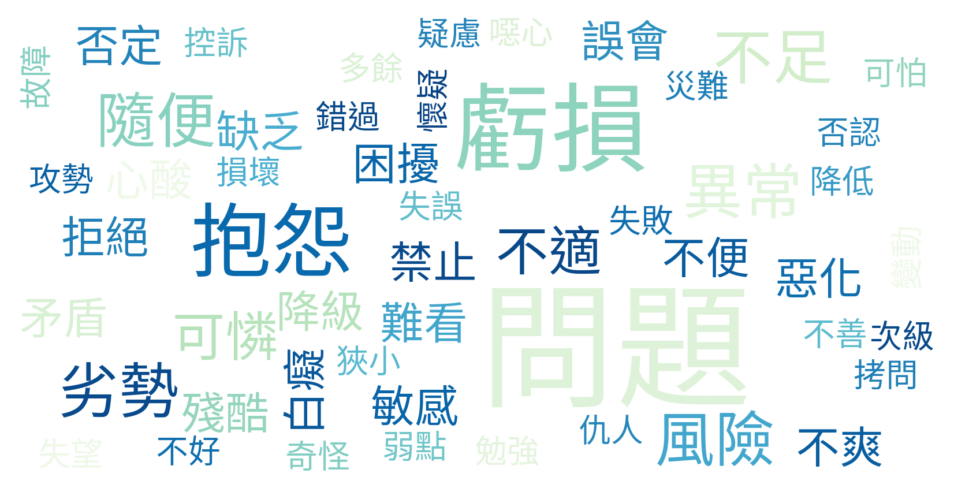

In [74]:
date = "2025-12-30"
end_date = "2026-03-18"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & ( # 時間區間
    ptt_liwc_df_revise['sentiment_class'] == "負向")  & ( # 負面文章
    ptt_liwc_df_revise['artContent'].str.contains('星宇')) & ( # 內文包含星宇
    ptt_liwc_df_revise["sentiments"] == "negative") # 負面情緒字

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["artDate", "word"]]
wc = ptt_df_wc.groupby(["word"]).size().to_dict()

# wordcloud 的 input 是 dictionary
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path, colormap="GnBu")
cloud.generate_from_frequencies(wc)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(
    cloud,
    interpolation="bilinear"
)
plt.axis("off")
plt.show()

```資訊發掘```
- 圖中最大的「虧損」與「風險」字眼顯示，負面聲量的核心並非一般客訴，而是大眾對公司財務與營運體質的質疑。
- 伴隨出現的「不足」、「缺乏」與「降級」，暗示在春節旺季期間發生了資源落差，導致旅客感受到服務量能的衰退。
- 而「抱怨」、「不爽」與「失望」等強烈情緒字眼，則反映出相關危機並未被及時平息，進而引發社群高度的負面共鳴。

利用「年終」去查看原文內容

In [75]:
sent_df = sent_df.reset_index(drop=True)

date = "2025-12-01"
end_date = "2026-03-18"
mask = (sent_df['artDate'] >= pd.Timestamp(date).date()) & (
    sent_df['artDate'] <= pd.Timestamp(end_date).date()) & (
    sent_df['sentiment_class'] == "負向") & (
    sent_df['sentence'].str.contains('年終')) # 包含「年終」的句子

df_ = sent_df.loc[mask, ["artDate", "artContent", "sentence"]]
index_list = df_.index.tolist()


# 取得前後各5筆的索引 => 目的為查看包含該詞彙句子的上下文
surrounding_indices = []
for index in index_list:
    surrounding_indices.extend(range(index - 5, index + 6))

# 去除重複的索引，並確保不超出範圍
surrounding_indices = list(set(filter(lambda x: x >= 0 and x < len(sent_df), surrounding_indices)))

# 依據索引取得相應的資料
result_df = sent_df.iloc[surrounding_indices].sort_index()
result_df[['artTitle', 'sentence', 'sentiment_class']]

,artTitle,sentence,sentiment_class
971,[新聞] 旅客注意！星宇1客機桃園起飛後「掉頭折,天氣跟機務維修又不一樣,負向
972,[新聞] 旅客注意！星宇1客機桃園起飛後「掉頭折,紐約預計今天晚上下雪,負向
973,[新聞] 旅客注意！星宇1客機桃園起飛後「掉頭折,氣象講得好像世界末日一樣,負向
974,[新聞] 旅客注意！星宇1客機桃園起飛後「掉頭折,天氣跟機務問題是可以混在一起的嗎00,負向
975,[新聞] 旅客注意！星宇1客機桃園起飛後「掉頭折,300雖然很少,負向
...,...,...,...
8656,[新聞] 星宇航空台中飛神戶重落地 民航局：組員,寧願坐長榮華航 給一個月 哈哈,負向
8657,[新聞] 星宇航空台中飛神戶重落地 民航局：組員,寧願搭長榮,負向
8658,[新聞] 星宇航空台中飛神戶重落地 民航局：組員,技術穩多了,負向
8659,[新聞] 星宇航空台中飛神戶重落地 民航局：組員,長榮不是有酒駕嗎,負向


```資訊發掘```
- 透過還原負面詞彙的上下文語境，我們發現「年終」議題已產生嚴重的負面擴散效應。
- 當品牌發生其他營運缺失（如重落地、航班折返）時，網友會立刻將其與勞資爭議連結，並轉而擁抱競品。

網友真實留言擷取：
"寧願坐長榮華航 給一個月 哈哈", "寧願搭長榮，技術穩多了", "年終一個月還想怎樣", "年終一個月，服務就是一個月態度"

## 3. 情緒分析 （二）

### 3.1 安裝CKIP

In [76]:
data_utils.download_data_gdown("./")  # 下載ckip model

Downloading...
From (original): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771
From (redirected): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771&confirm=t&uuid=7cab1543-516b-4148-990d-d8d396b33169
To: c:\Users\lcswa\Desktop\SMA_G2_PRJ1\data.zip
100%|██████████| 1.88G/1.88G [01:29<00:00, 21.0MB/s]


In [77]:
# 將三份工具的模型路徑指向我們剛才下載的檔案「data」
ws = WS("./data")
pos = POS("./data")
ner = NER("./data")

c:\Users\lcswa\anaconda3\envs\Mproject\Lib\site-packages\ckiptagger\model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
c:\Users\lcswa\anaconda3\envs\Mproject\Lib\site-packages\ckiptagger\model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
c:\Users\lcswa\anaconda3\envs\Mproject\Lib\site-packages\ckiptagger\model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.n

### 3.1 將抓取結果用CKIP進行處理

In [78]:
# 讀取星宇航空的 PTT 文章資料
df = pd.read_csv("raw_data/starlux_dataset.csv")

# 將 artDate 轉換為 datetime 格式，並只保留日期部分
df["artDate"] = pd.to_datetime(df["artDate"])
df['artDate'] = df['artDate'].dt.date 

#去除文章內容為空值的筆數
df.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

# 新增 sentence 欄位：先把跳脫字元換回換行，再做清理
df['sentence'] = df['artContent'].str.replace(r'\\n', '\n', regex=True)
df['sentence'] = df['sentence'].str.replace(r'\n\n', '。', regex=True)
df['sentence'] = df['sentence'].str.replace(r'\n', '', regex=True)


#移除內文中的網址
df['sentence'] = df['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

df.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,sentence
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣。星宇 星加坡 長榮會怎麼選呢?。看票價星宇是便宜蠻多的 不明白怎麼差那麼多...
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的 我最近也有注意到
3,3,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,susan06374,金城武都選長榮 你參考,金城武都選長榮 你參考
4,4,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,MTBF,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到


定義文字清理的相關function

In [79]:
def Segmentation_Core(data, tokenizer):
    # 將所有的斷行字元配上 escape 以防失效
    regexPattern = '|'.join(map(re.escape, tokenizer))
    output_list = re.split(regexPattern, data)
    # 過濾空白行
    output_list = list(filter(None, output_list))
    return output_list

def Sentence_Segmentation(article, keep_digits=False, keep_alphabets=False):
    """ Sentence_Segmentation function 用於執行中文斷行任務

    順序如下：
    1. 去除(\\n)
    2. 去除特殊符號字元
    3. 保留數字
    4. 依照斷句字元進行斷句全形的分號、逗號、句號、問號以及驚嘆號
    5. 避免空白斷句結果

    Args:
        article(string): 欲斷行之文章內容
        keep_digits(Boolean): 決定是否保留數字於斷行後的結果
        keep_alphabets(Boolean): 決定是否保留字母於斷行後的結果
    Returns:
        List [] 每個 element 就是一行
    """
    if not isinstance(article, str):
        article = str(article)
    sepical_symbols = r'[.＂<>:《》+\-=#$%&()*@＃＄％＆＇\(\)\[\]\{\}（）＊＋－／：\
    ＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿–—一‘’‛“”„‟…‧﹏★→─]+'
    segmentation_used_note = (";", "；", "！", "!", "？", "?", "。")


    paragraphs = list(filter(lambda x: re.sub(r'\s+','', x), article.split("\n")))
    # print(len(paragraphs))
    # print(paragraphs)

    result = []
    for paragraph in paragraphs:

        clean_paragraph = paragraph
        try:
            if not keep_digits:
                clean_paragraph = re.sub(r'\d*\.?\d+','', clean_paragraph) #remove space & digits
            if not keep_alphabets:
                clean_paragraph = re.sub('[a-zA-Z]+', '', clean_paragraph)

            clean_paragraph = re.sub(r'[\s]+','', clean_paragraph) #remove space


            clean_paragraph = re.sub(sepical_symbols,'',clean_paragraph)

        except:
            return "error"

        res = Segmentation_Core(clean_paragraph, segmentation_used_note)
        res = [s for s in res if len(s.strip()) > 1 and re.search(r'[\u4e00-\u9fff]', s)]

        if res:
            result.append(res)


    return result

CKIP 處理相關function

In [80]:
# 自定義辭典
with open('./dict/user_dict.txt') as f:
    lines = f.read().splitlines()

dict = {k.split()[0]: k.split()[1] for v, k in enumerate(lines)}
dictionary2 = construct_dictionary(dict)
print(dictionary2)

[(4, {'星宇航空': 100.0, '長榮航空': 100.0, '航空公司': 100.0, '年終獎金': 100.0})]


In [81]:
from tqdm import tqdm

def get_pos(post_id, word_sentence, pos_sentence):
    tokens = []
    # print("\nPOS: ", end="\u3000")
    assert len(word_sentence) == len(pos_sentence)
    for word, pos in zip(word_sentence, pos_sentence): # token level
        tokens.append([post_id, word, pos])
    # print(f"{word}({pos})", end="\u3000")
    return tokens

def get_ner(post_id, entity_sentence):
    entities = []
    # print("\nNER:___________ ")
    for entity in sorted(entity_sentence): # token level
        entities.append([post_id, entity[3], entity[2]])
    return entities

def get_nlp_result(data_df):
    start = time.time()

    pos_list = []
    entity_list = []
    sentence_list = []

    # 遍歷 dataframe 的每筆資料
    for index, row in tqdm(data_df.iterrows(), total=len(data_df)):
    # print(f"\ndocument {index}")

        # 資料清理 ＆ 斷句
        tmp = Sentence_Segmentation(row['artContent'], keep_digits=True, keep_alphabets=True)
        flat_list = [item for sublist in tmp for item in sublist]

        # ckip
        word_sentence_list = ws(flat_list, coerce_dictionary = dictionary2)
        pos_sentence_list = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        # 遍歷該 document 中的每一個句子
        for i, sentence in enumerate(flat_list):
            # print(f"sentence {i}: {sentence}")
            sentence_list.append([row['system_id'], sentence])
            temp_tokens = get_pos(row['system_id'], word_sentence_list[i], pos_sentence_list[i])
            temp_entites = get_ner(row['system_id'], entity_sentence_list[i])

            pos_list.append(temp_tokens)
            if len(temp_entites) != 0:
                entity_list.append(temp_entites)

    pos_flat = [item for sublist in pos_list for item in sublist]
    entity_flat = [item for sublist in entity_list for item in sublist]

    pos_table = pd.DataFrame(data=pos_flat,
                    columns=['system_id','word','pos'])

    entity_table = pd.DataFrame(data=entity_flat,
                        columns=['system_id','word','ner'])

    sentence_table = pd.DataFrame(data=sentence_list,
                    columns=['system_id','sentence'])

    end = time.time()
    print("time costing: {}".format(end - start))

    return pos_table, entity_table, sentence_table

In [82]:
# 看看 tmp 和 flat_list 有什麼差別
tmp = Sentence_Segmentation(df['artContent'][0])
flat_list = [item for sublist in tmp for item in sublist]
print(tmp[:5])
print(flat_list[:5])

[['請問新加坡飛台灣\\\\星宇星加坡長榮會怎麼選呢', '\\\\看票價星宇是便宜蠻多的不明白怎麼差那麼多\\\\但是如果選星宇累計的里程和星加坡長榮應該是分開的', '\\\\論位置的話,這三家哪個會比較大呢\\\\還是都用班機時刻選\\\\請問大家會怎麼選\\\\感謝']]
['請問新加坡飛台灣\\\\星宇星加坡長榮會怎麼選呢', '\\\\看票價星宇是便宜蠻多的不明白怎麼差那麼多\\\\但是如果選星宇累計的里程和星加坡長榮應該是分開的', '\\\\論位置的話,這三家哪個會比較大呢\\\\還是都用班機時刻選\\\\請問大家會怎麼選\\\\感謝']


In [ ]:
pos_table, entity_table, sentence_table = get_nlp_result(df)

 29%|██▊       | 1166/4083 [04:30<09:01,  5.39it/s]  

+ 欄位名稱介紹
    + pos_table 欄位:
        + system_id : ptt 貼文id
        + word: 原始斷詞
        + pos : part-of-speech,詞性
    + entity_table 欄位:
        + system_id : ptt 貼文id
        + word: 原始斷詞
        + ner: 命名實體
    + sentence_table 欄位:
        + system_id : ptt 貼文id
        + text: 原始斷句

In [ ]:
pos_table.head() # word pos 列表

In [ ]:
entity_table.head() # word entity 列表

In [ ]:
sentence_table.head()

In [ ]:
# 檢查筆數
print(f"total posts numbers: {len(pos_table['system_id'].unique())}") # 1628篇文
print(f"posts have NER: {len(entity_table['system_id'].unique())}") # 1620篇有抓到ner

In [ ]:
# 將文章存成csv
pos_table.to_csv('raw_data/pos_table_starlux.csv', index = False)
entity_table.to_csv('raw_data/entity_table_starlux.csv', index = False)
sentence_table.to_csv('raw_data/sentence_table_starlux.csv', index = False)

### 3.2 探索分析 - NER

In [ ]:
# 讀取已經執行完畢的結果
pos_table = pd.read_csv("raw_data/pos_table_starlux.csv")
entity_table = pd.read_csv("raw_data/entity_table_starlux.csv")
sentence_table = pd.read_csv("raw_data/sentence_table_starlux.csv")

### NER 種類分析
查看標註這個文集後辨識出哪一些實體種類<br>
名詞對應: https://ckip.iis.sinica.edu.tw/service/corenlp/ （左上角的標記列表）

In [ ]:
entity_table['ner'].unique()

In [ ]:
ner_count = entity_table.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count

In [ ]:
ner = ner_count['ner']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(ner, count)
ax.invert_yaxis()
ax.set_title('NER Frequency of PTT Starlux',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
# fig.show()

### 涉及到的民族、宗教、政治團體(NORP)

In [ ]:
# 篩選ner為NORP的資料
l_noun = ["NORP"]
NORP = entity_table[entity_table.ner.isin(l_noun)]

# # 計算每個名詞提到的次數，選出前10個
ner_count = NORP.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(10).reset_index()
ner_count

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is NORP)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

麥當勞是全球的連鎖店，可以看出日本麥當勞是討論最多的話題，有可能是因為很常與動漫聯名，並且日本麥當勞兒童餐「家家酒玩具」預計在2025 年2 月底至3 月中旬推出，可能也是大家討論的議題之一。

### 涉及到的組織(ORG)

In [ ]:
# 篩選ner為ORG的資料
l_noun = ["ORG"]
ORG = entity_table[entity_table.ner.isin(l_noun)]

# # 計算每個名詞提到的次數，選出前10個
ner_count = ORG.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(10).reset_index()
ner_count

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is ORG)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

除了麥當勞之外，還有同樣是速食餐廳也有被提及，像是「肯德基」、「漢堡王」、「摩斯漢堡」。

### 涉及到的人物(PERSON)

In [ ]:
# 篩選ner為PERSON的資料
l_noun = ["PERSON"]
PERSON = entity_table[entity_table.ner.isin(l_noun)]

# 計算每個名詞提到的次數，選出前8個
ner_count = PERSON.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(8).reset_index()

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is PERSON)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

- 美國總統當選人川普熱愛麥當勞成痴，不但在競選期間跑去麥當勞店面打工，平時也會享用他鍾愛的「川普套餐」，甚至分享給內閣首長和朋友。


In [ ]:
keyword_list = ['日本']
shu_selected = df[df['artContent'].str.contains('|'.join(keyword_list), regex=True, na=False)]
print(f"{' '.join(keyword_list)}：{shu_selected.shape[0]}篇相關貼文")
shu_selected.head()

### 3.3 探索分析 - POS

#### POS 種類分析
查看辨識出哪幾種POS<br>
名詞對應: https://ckip.iis.sinica.edu.tw/service/corenlp/ （左上角的標記列表）

In [ ]:
pos_table['pos'].unique()

In [ ]:
pos_filter = pos_table[~pos_table.pos.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]

pos_count = pos_filter.groupby(['pos'])['pos'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count

#### POS 常見詞性列表
+ Na: 普通名詞
+ D: 副詞
+ VC: 動作及物動詞
+ Nb: 專有名詞
+ FW: 外文
+ VH: 狀態不及物動詞
+ Nh: 代名詞
+ DE: 的之得地
+ P: 介詞
+ VA: 動作不及物動詞
+ T: 語助詞
+ SHI: 是

In [ ]:
pos = pos_count['pos']
count = pos_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(pos, count)
ax.invert_yaxis()
ax.set_title('ner Frequency',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
fig.show()

### 涉及到的名詞(Noun)
+ 我們可以找出談論麥當勞大部分討論到的名詞，探索大家的關注焦點。
+ 名詞可以分為「Na: 普通名詞」、「Nb: 專有名詞」等

In [ ]:
# 篩選pos為專有名詞的資料
l_noun = ["Nb"] #,"Na"
noun = pos_table[pos_table.pos.isin(l_noun)]

# 計算每個名詞提到的次數，選出前15個
noun_count = noun[['word']].groupby(['word'])['word'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(15)
noun_count.head(10)

In [ ]:
# 設定文字雲中文字體路徑
font_path = "raw_data/SourceHanSansTW-Regular.otf"

# 設定圖的字體大小
plt.rcParams['font.size'] = 14

# 1) 將字體檔案加入到 matplotlib 的字體庫
fm.fontManager.addfont(font_path)

# 2) 建立 FontProperties 物件
fprop = fm.FontProperties(fname=font_path)

# 3) 設定整體的 font.family 為此字體
plt.rcParams['font.family'] = fprop.get_name()

In [ ]:
# 設定中文字形
word = noun_count['word']
count = noun_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (POS is NOUN)',loc ='left', size = 14)
ax.set_ylabel('POS', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
fig.show()

可以看出大家很常討論的品項是「大麥克」，和「甜心卡」是麥當勞常客會買的商品。

### 涉及到的動詞(VERB)
+ 我們可以找出談論麥當勞時大部分討論到的動詞，探索相關行為。
+ VC: 動作及物動詞、VH: 狀態不及物動詞、VA: 動作不及物動詞

In [ ]:
l_verb = ["VC"] # ,"VH","VA"
verb = pos_table[pos_table.pos.isin(l_verb)] # 選取特定詞性
verb = verb[verb['word'].map(len) > 1] # 把長度為1的字去除掉

verb_count = verb[['word']].groupby(['word'])['word'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(15)
verb_count

In [ ]:
word = verb_count['word']
count = verb_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (POS is VC)',loc ='left', size = 14)
ax.set_ylabel('organization', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
fig.show()

可以看到「推出」提及率很高，也可以聯想到麥當勞推出新產品時會被廣泛討論，試吃心得。

## 4. 利用SnowNLP進行情緒分析

+ SnowNLP 針對中文設計，可以提取句子的情緒分類
+ 使用文件分類法，套件已預先用文集訓練模型以判斷情緒
+ 情緒值在 0~1之間，代表負面到正面
+ 官方github: https://github.com/isnowfy/snownlp

In [ ]:
sentence_table = pd.read_csv("raw_data/sentence_table_starlux.csv") #匯資料

sentiment_date = pd.merge(sentence_table,shu_selected[['system_id','artDate']],on='system_id',how='left').dropna()

sentiment_date.head()

In [ ]:
from snownlp import SnowNLP
def get_sentiment(sent):
    s = SnowNLP(sent)
    return s.sentiments

# 幫每句話加上情緒分數
sentiment_date['sentimentValue'] = sentiment_date.apply(lambda row : get_sentiment(row['sentence'],), axis = 1)
sentiment_date.head(3)

In [ ]:
# 看一下情緒的分布
sentiment_date['sentimentValue'].describe()

In [ ]:
# 情緒分布的盒狀圖
boxplot = sentiment_date.boxplot(column=['sentimentValue'], showfliers=False)
boxplot

將每個月的情緒分數取平均，並轉換時間格式為年月

In [ ]:
sent_date = sentiment_date.copy()
sent_date['artDate'] =  pd.to_datetime(sentiment_date['artDate']).dt.to_period('M')

sentiment_count = sent_date.groupby(['artDate'])['sentimentValue'].mean().reset_index()
sentiment_count

In [ ]:
# 平均情緒分數時間趨勢
months = [period.to_timestamp() for period in sentiment_count['artDate']]   # 將 PeriodIndex 中的每個 Period 物件轉換為對應的 datetime 物件
y = sentiment_count['sentimentValue']

plt.style.use('seaborn-v0_8')

plt.plot_date(months, y, linestyle='solid')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.ylim(0, 1)

plt.show()

### 詞彙探索
從上圖中可以發現 2026年1月 的情緒分數相對高，我們把這個月的正面句子挑出來看看他們都用甚麼詞。

In [ ]:
# 篩時間
filter_sentiment = sent_date[sent_date['artDate']=='2026-01']
filter_sentiment = filter_sentiment.loc[filter_sentiment['sentimentValue'] > 0.7]

filter_sentiment.head()

In [ ]:
# 把時間分數和之前斷詞的 token table 做 join
pos_words = pd.merge(filter_sentiment,pos_table,on='system_id',how='left')
pos_words = pos_words[['system_id','sentimentValue','word']]
pos_words.head()

In [ ]:
# 篩選掉只有單個字元的結果
pos_words = pos_words[pos_words.apply(lambda x: len(x['word'])>1, axis=1)]

### 正面詞彙文字雲

In [ ]:
# 自定停用字
with open('dict/stopwords.txt') as f:
    stop_words = f.read().splitlines()

print(stop_words[:20])

In [ ]:
stop_words_pos = stop_words
stop_words_pos.extend(('麥當勞','sanajp', 'wwwpttcc', 'https', '網址', 'html', 'app', 'bbs',"整整","AC","XD","Aeon系列","意外","今天","日本","以為","差距",'Aeon', '美食街', 'fastfood', '商品圖','中姬', '中規','甜甜','系列', '商品圖', '出月', '編輯', '知道','喝完', '可怕','文章','肯德基',"白玉超",'甜味','小時','隔壁','M','拿到','配上','組合','中和','實物'))
stop_words_pos = set(stop_words_pos)

# 可以設定字型大小和背景顏色
wordcloud = WordCloud(
                stopwords=stop_words_pos,
                collocations=False,
                font_path=font_path,
                width=800,
                height = 400,
                max_words=100,
                background_color="white")

wordcloud.generate(' '.join(pos_words['word']))
# Display the generated image:
plt.figure(figsize = (14,7))
plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.show()

https://www.letsgojp.com/archives/687883

日本麥當勞在2024年9月推出新品「月見系列」，能看得出新產品廣受大家歡迎，其中包含了卡士達布丁奶昔、黃豆麻糬佐豆沙月見派。